# MLP Regression with TensorFlow/Keras

A `CustomMLP` wrapper around `tf.keras.Sequential`, trained on a **synthetic nonlinear regression** problem. Unlike a naive random-noise dataset, the target `y` here is a real nonlinear function of the inputs plus a little noise -- so R² on a held-out test set is a meaningful check of whether the network learned it, not just memorized training data.

## 1. Imports

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## 2. The CustomMLP class

In [2]:
class CustomMLP:
    """
    Custom Multi-Layer Perceptron (MLP) for regression using TensorFlow/Keras.

    Attributes:
    - input_size: Number of input features.
    - hidden_layers: List defining the number of neurons in each hidden layer.
    - output_size: Number of output neurons.
    - activation_functions: List defining activation functions for each layer.
    """

    def __init__(self, input_size, hidden_layers, output_size, activation_functions):
        """
        Initializes the MLP model with the given structure and activation functions.

        Parameters:
        - input_size: Number of input features.
        - hidden_layers: List specifying the number of neurons in each hidden layer.
        - output_size: Number of neurons in the output layer.
        - activation_functions: List defining the activation functions for each layer.
        """
        self.model = models.Sequential()  # Create a Sequential model

        # Add the first hidden layer
        self.model.add(layers.Input(shape=(input_size,)))
        self.model.add(layers.Dense(hidden_layers[0], activation=activation_functions[0]))

        # Add subsequent hidden layers
        for i in range(1, len(hidden_layers)):
            self.model.add(layers.Dense(hidden_layers[i], activation=activation_functions[i]))

        # Add the output layer (Linear activation for regression)
        self.model.add(layers.Dense(output_size, activation='linear'))

        # Compile the model with Mean Squared Error loss and Adam optimizer
        self.model.compile(optimizer=optimizers.Adam(), loss='mse')

        # Store training loss history
        self.history = None

    def train_model(self, X, y, epochs=100, batch_size=20, validation_data=None):
        """
        Trains the MLP using the given dataset.

        Parameters:
        - X: Input feature matrix.
        - y: Target values.
        - epochs: Number of training iterations.
        - batch_size: Size of each batch for mini-batch training.
        - validation_data: Optional (X_val, y_val) tuple monitored during training.
        """
        self.history = self.model.fit(
            X, y,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=validation_data,
            verbose=1,
        )

    def plot_training_mse(self):
        """
        Plots the Mean Squared Error (MSE) loss over training epochs.
        """
        plt.plot(self.history.history['loss'], label='Train Loss')
        if 'val_loss' in self.history.history:
            plt.plot(self.history.history['val_loss'], label='Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Mean Squared Error')
        plt.title('Training MSE Over Epochs')
        plt.legend()
        plt.show()

    def evaluate_model(self, X, y):
        """
        Evaluates the model on a given dataset.

        Parameters:
        - X: Input feature matrix.
        - y: Target values.

        Prints:
        - Mean Squared Error for the dataset.
        """
        mse = self.model.evaluate(X, y, verbose=0)
        print(f'Mean Squared Error on Evaluation Data: {mse:.4f}')

    def plot_predictions(self, X, y, title_suffix=''):
        """
        Plots actual vs. predicted values and prints performance metrics.

        Parameters:
        - X: Input feature matrix.
        - y: Target values.
        - title_suffix: Text appended to plot titles (e.g. 'Test Set').
        """
        predictions = self.model.predict(X, verbose=0)

        # Line plot: actual vs predicted
        plt.plot(y, label='Actual')
        plt.plot(predictions, label='Predicted', color='red')
        plt.xlabel('Sample Index')
        plt.ylabel('Value')
        plt.title(f'Actual vs. Predicted Values {title_suffix}')
        plt.legend()
        plt.show()

        # Scatter plot: actual vs predicted
        plt.scatter(y, predictions, alpha=0.7)
        plt.xlabel('Actual Values')
        plt.ylabel('Predicted Values')
        plt.title(f'Scatter Plot of Predictions vs Actual {title_suffix}')
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--')  # Diagonal reference line
        plt.grid(True)
        plt.show()

        # Calculate regression metrics
        mse = mean_squared_error(y, predictions)
        mae = mean_absolute_error(y, predictions)
        r2 = r2_score(y, predictions)

        # Print regression metrics
        print(f"Mean Squared Error (MSE): {mse:.4f}")
        print(f"Mean Absolute Error (MAE): {mae:.4f}")
        print(f"R² Score: {r2:.4f}")

## 3. Generate synthetic nonlinear data + train/test split

`y` is a nonlinear function of the 5 input features plus small noise: `y = 3*x1 - 2*x2^2 + sin(x3) + 0.5*x4*x5 + noise`. We split into train/test **before** training, so the evaluation later reflects generalization, not memorization.

In [3]:
np.random.seed(20250303)  # Set random seed for reproducibility

n_samples, n_features = 300, 5
X = np.random.uniform(-3, 3, size=(n_samples, n_features))

# True (nonlinear) relationship the network has to discover:
# y = 3*x1 - 2*x2^2 + sin(x3) + 0.5*x4*x5 + noise
noise = np.random.normal(0, 0.3, size=n_samples)
y = (
    3 * X[:, 0]
    - 2 * X[:, 1] ** 2
    + np.sin(X[:, 2])
    + 0.5 * X[:, 3] * X[:, 4]
    + noise
).reshape(-1, 1)

# Convert NumPy arrays to TensorFlow-compatible arrays
X = X.astype(np.float32)
y = y.astype(np.float32)

# Split into train/test sets so evaluation reflects generalization, not memorization
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=20250303
)

## 4. Build & train the model

In [4]:
# Define model parameters
input_size = n_features  # Number of input features
hidden_layers = [64, 32]  # Hidden layer sizes
output_size = 1  # Single output neuron
activation_functions = ['relu', 'relu']  # Activation functions for hidden layers

# Instantiate the MLP model
model = CustomMLP(input_size, hidden_layers, output_size, activation_functions)

# Train the model, tracking validation loss on the held-out test set
model.train_model(
    X_train, y_train,
    epochs=200, batch_size=20,
    validation_data=(X_test, y_test),
)

Epoch 1/200


 1/12 ━━━━━━━━━━━━━━━━━━━━ 4s 435ms/step - loss: 57.7331

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 98.8525 - val_loss: 71.3321


Epoch 2/200


 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 67.5484

...

 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.2490

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2192 - val_loss: 0.8589


Epoch 200/200


 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1255

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.2219 - val_loss: 0.8312


## 5. Evaluate & visualize on the test set

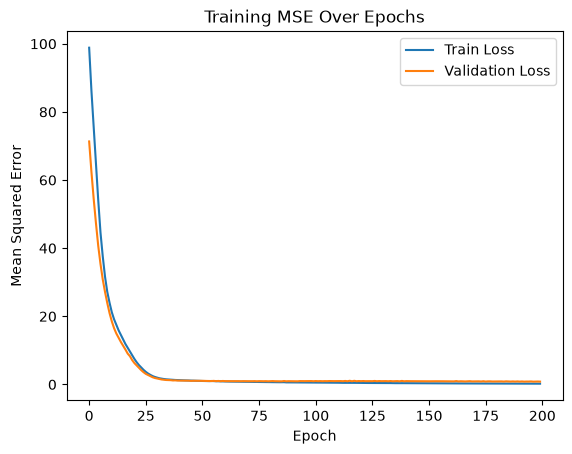

Mean Squared Error on Evaluation Data: 0.8312

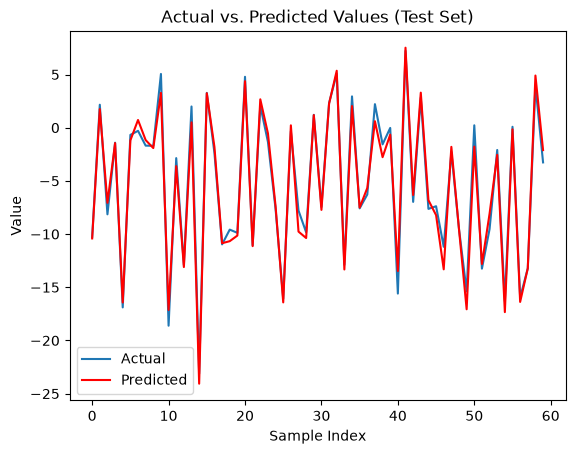

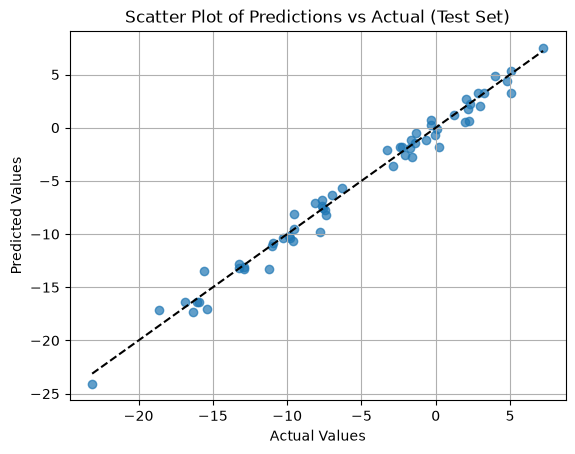

Mean Squared Error (MSE): 0.8312
Mean Absolute Error (MAE): 0.7069
R² Score: 0.9836


In [5]:
# Plot the training/validation MSE
model.plot_training_mse()

# Evaluate model performance on the held-out test data
model.evaluate_model(X_test, y_test)

# Plot actual vs. predicted values and metrics on the TEST set (unseen data)
model.plot_predictions(X_test, y_test, title_suffix='(Test Set)')